# GHRSST MUR JPL L4 SST Analysis and Visualization

**Product:** MUR-JPL-L4-GLOB-v4.1 (Multi-scale Ultra-high Resolution SST)  
**Resolution:** 0.01° global grid (~36000 × 18000 pixels per file)  
**Frequency:** Daily files  

This notebook:
1. Explores the NetCDF dataset structure
2. Creates monthly mean SST maps (12-panel figure)
3. Creates daily SST maps for a user-specified date range

---
## Import Libraries

In [1]:
import os
import re
import glob
import warnings
from datetime import datetime
from math import ceil
from calendar import month_name

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import Normalize

# Suppress non-critical warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

print("Libraries loaded successfully!")

Libraries loaded successfully!


---
## Configuration Block

**Edit only this cell** to customize the analysis for your data.

In [18]:
# =============================================================================
# CONFIGURATION (User edits only here)
# =============================================================================

# Paths
DATA_DIR = r"C:\Users\abhik\Downloads\New_folder\MUR-JPL-L4-GLOB-v4.1_4.1-20260316_132446"
OUTPUT_DIR = r"C:\Users\abhik\Downloads\New_folder\SST_Plots"

# Region of interest: [lon_min, lon_max, lat_min, lat_max] or None for global
# Bay of Bengal: [80, 100, 5, 25]
# Indian Ocean: [40, 100, -10, 30]
REGION = [80, 100, 5, 25]  # Set to None for global view

# Year to analyze
YEAR = 2024

# Colormap settings
SST_CMAP = "RdYlBu_r"  # Colormap for SST (red=warm, blue=cold)

# Initial colorbar range (will be refined in SST Statistics Analysis section)
# For Bay of Bengal region, typical range is 26-32°C
# For global, use -2 to 32°C
SST_VMIN = 10.0      # Minimum SST in °C (update after running statistics)
SST_VMAX = 32.0        # Maximum SST in °C (update after running statistics)

# Performance: spatial downsampling factor (1=full resolution, 5=fast, 10=very fast)
DOWNSAMPLE = 5

# Daily plot configuration
DAILY_MONTH = 10       # Month number (1-12) for daily visualization
DAILY_DAY_START = 1    # Start day of range
DAILY_DAY_END = 30     # End day of range
DAYS_PER_ROW = 5       # Number of subplot columns in daily panel figure

# Print configuration summary
print("Configuration:")
print(f"  Data directory: {DATA_DIR}")
print(f"  Output directory: {OUTPUT_DIR}")
print(f"  Region: {'Global' if REGION is None else REGION}")
print(f"  Year: {YEAR}")
print(f"  Downsample factor: {DOWNSAMPLE}")
print(f"  SST range: {SST_VMIN}°C to {SST_VMAX}°C")
print(f"  Daily plot: {month_name[DAILY_MONTH]} {YEAR}, days {DAILY_DAY_START}-{DAILY_DAY_END}")

Configuration:
  Data directory: C:\Users\abhik\Downloads\New_folder\MUR-JPL-L4-GLOB-v4.1_4.1-20260316_132446
  Output directory: C:\Users\abhik\Downloads\New_folder\SST_Plots
  Region: [80, 100, 5, 25]
  Year: 2024
  Downsample factor: 5
  SST range: 10.0°C to 32.0°C
  Daily plot: October 2024, days 1-30


---
## Block 1: Helper Functions

Core functions for:
- Extracting dates from filenames
- Loading SST data with region subsetting and downsampling
- Creating map visualizations
- Filtering files by month

In [5]:
def extract_date_from_filename(filepath):
    """
    Parse YYYYMMDD from the first 8 characters of the filename.
    
    Parameters
    ----------
    filepath : str
        Full path to the NetCDF file
    
    Returns
    -------
    datetime
        Python datetime object representing the file date
    """
    filename = os.path.basename(filepath)
    match = re.match(r'^(\d{8})', filename)
    if match:
        date_str = match.group(1)
        return datetime.strptime(date_str, '%Y%m%d')
    else:
        raise ValueError(f"Cannot parse date from filename: {filename}")

In [6]:
def load_sst(filepath, region=None, downsample=1):
    """
    Load SST data from a NetCDF file with optional region subsetting and downsampling.
    
    Parameters
    ----------
    filepath : str
        Path to the NetCDF file
    region : list or None
        [lon_min, lon_max, lat_min, lat_max] for subsetting, or None for full domain
    downsample : int
        Spatial subsampling factor (1=full resolution)
    
    Returns
    -------
    xr.DataArray
        SST data in degrees Celsius, with time dimension squeezed
    """
    ds = xr.open_dataset(filepath)
    
    # Extract SST and squeeze the time dimension (always size 1)
    sst = ds['analysed_sst'].squeeze('time')
    
    # Subset to region if specified
    if region is not None:
        lon_min, lon_max, lat_min, lat_max = region
        sst = sst.sel(lon=slice(lon_min, lon_max), lat=slice(lat_min, lat_max))
    
    # Convert Kelvin to Celsius
    sst = sst - 273.15
    
    # Apply spatial downsampling
    if downsample > 1:
        sst = sst[::downsample, ::downsample]
    
    # Close the dataset to free memory
    ds.close()
    
    return sst

In [7]:
def make_sst_map(ax, sst_data, title, vmin, vmax, cmap, show_cbar=False):
    """
    Create an SST map on a Cartopy axis with coastlines, borders, and gridlines.
    
    Parameters
    ----------
    ax : matplotlib.axes.Axes
        Cartopy GeoAxes object
    sst_data : xr.DataArray
        SST data to plot (must have lat/lon coordinates)
    title : str
        Title for the subplot
    vmin, vmax : float
        Colorbar range (min/max SST in °C)
    cmap : str
        Matplotlib colormap name
    show_cbar : bool
        Whether to add an individual colorbar (default False for shared colorbar)
    
    Returns
    -------
    matplotlib.collections.QuadMesh
        The pcolormesh image handle (useful for shared colorbar)
    """
    # Get coordinate arrays
    lon = sst_data.coords['lon'].values
    lat = sst_data.coords['lat'].values
    
    # Add map features
    ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=1)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5, zorder=2)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3, linestyle='--', zorder=2)
    
    # Add gridlines
    gl = ax.gridlines(draw_labels=True, linewidth=0.3, color='gray',
                      alpha=0.5, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {'size': 7}
    gl.ylabel_style = {'size': 7}
    
    # Plot SST data
    img = ax.pcolormesh(lon, lat, sst_data.values,
                        transform=ccrs.PlateCarree(),
                        cmap=cmap, vmin=vmin, vmax=vmax,
                        shading='auto', zorder=0)
    
    # Set title
    ax.set_title(title, fontsize=10, fontweight='bold')
    
    # Optional individual colorbar
    if show_cbar:
        plt.colorbar(img, ax=ax, orientation='horizontal',
                     label='SST (°C)', pad=0.05, shrink=0.8)
    
    return img

In [8]:
def get_files_for_month(all_files, year, month):
    """
    Filter files to get those matching a specific year and month.
    
    Parameters
    ----------
    all_files : list
        List of all NetCDF file paths
    year : int
        Year to filter (e.g., 2024)
    month : int
        Month to filter (1-12)
    
    Returns
    -------
    dict
        Dictionary mapping day number (int) to filepath
    """
    month_files = {}
    for filepath in all_files:
        try:
            file_date = extract_date_from_filename(filepath)
            if file_date.year == year and file_date.month == month:
                month_files[file_date.day] = filepath
        except ValueError:
            continue
    return month_files

print("Helper functions defined successfully!")

Helper functions defined successfully!


---
## Block 2: Data Exploration

Discover and explore the GHRSST MUR dataset:
- Total file count
- Date range
- Available months
- NetCDF structure and variables

In [9]:
# Find all NetCDF files
pattern = os.path.join(DATA_DIR, "*.nc")
all_files = sorted(glob.glob(pattern))

print(f"Total files found: {len(all_files)}")

if len(all_files) == 0:
    print("\nERROR: No .nc files found in the specified directory!")
    print(f"Directory: {DATA_DIR}")
else:
    print(f"\nFirst file: {os.path.basename(all_files[0])}")
    print(f"Last file: {os.path.basename(all_files[-1])}")

Total files found: 367

First file: 20240101090000-JPL-L4_GHRSST-SSTfnd-MUR-GLOB-v02.0-fv04.1.nc
Last file: 20250101090000-JPL-L4_GHRSST-SSTfnd-MUR-GLOB-v02.0-fv04.1.nc


In [10]:
# Parse dates from filenames and display date range
dates = []
for f in all_files:
    try:
        dates.append(extract_date_from_filename(f))
    except ValueError:
        pass

if dates:
    dates_sorted = sorted(dates)
    print(f"Date range: {dates_sorted[0].strftime('%Y-%m-%d')} → {dates_sorted[-1].strftime('%Y-%m-%d')}")
    
    # List available months
    months_avail = sorted(set((d.year, d.month) for d in dates))
    print(f"\nMonths available ({len(months_avail)} total):")
    for y, m in months_avail:
        count = sum(1 for d in dates if d.year == y and d.month == m)
        print(f"  {y}-{m:02d}: {count} files")

Date range: 2024-01-01 → 2025-01-01

Months available (13 total):
  2024-01: 31 files
  2024-02: 29 files
  2024-03: 31 files
  2024-04: 30 files
  2024-05: 31 files
  2024-06: 30 files
  2024-07: 31 files
  2024-08: 31 files
  2024-09: 30 files
  2024-10: 31 files
  2024-11: 30 files
  2024-12: 31 files
  2025-01: 1 files


In [11]:
# Open one sample file to explore structure
if len(all_files) > 0:
    sample_file = all_files[0]
    print(f"Sample file: {os.path.basename(sample_file)}\n")
    
    ds = xr.open_dataset(sample_file)
    print(ds)

Sample file: 20240101090000-JPL-L4_GHRSST-SSTfnd-MUR-GLOB-v02.0-fv04.1.nc

<xarray.Dataset> Size: 29GB
Dimensions:           (time: 1, lat: 17999, lon: 36000)
Coordinates:
  * time              (time) datetime64[ns] 8B 2024-01-01T09:00:00
  * lat               (lat) float32 72kB -89.99 -89.98 -89.97 ... 89.98 89.99
  * lon               (lon) float32 144kB -180.0 -180.0 -180.0 ... 180.0 180.0
Data variables:
    analysed_sst      (time, lat, lon) float64 5GB ...
    analysis_error    (time, lat, lon) float64 5GB ...
    mask              (time, lat, lon) float32 3GB ...
    sea_ice_fraction  (time, lat, lon) float64 5GB ...
    dt_1km_data       (time, lat, lon) timedelta64[ns] 5GB ...
    sst_anomaly       (time, lat, lon) float64 5GB ...
Attributes: (12/47)
    Conventions:                CF-1.7
    title:                      Daily MUR SST, Final product
    summary:                    A merged, multi-sensor L4 Foundation SST anal...
    references:                 http://podaac.jpl

In [12]:
# Display variable details
if len(all_files) > 0:
    print("VARIABLE DETAILS")
    print("=" * 50)
    
    for var_name in ds.data_vars:
        var = ds[var_name]
        units = var.attrs.get('units', 'N/A')
        long_name = var.attrs.get('long_name', 'N/A')
        print(f"\n{var_name}:")
        print(f"  Units: {units}")
        print(f"  Long name: {long_name}")
        print(f"  Shape: {var.shape}")
    
    ds.close()

VARIABLE DETAILS

analysed_sst:
  Units: kelvin
  Long name: analysed sea surface temperature
  Shape: (1, 17999, 36000)

analysis_error:
  Units: kelvin
  Long name: estimated error standard deviation of analysed_sst
  Shape: (1, 17999, 36000)

mask:
  Units: N/A
  Long name: sea/land field composite mask
  Shape: (1, 17999, 36000)

sea_ice_fraction:
  Units: N/A
  Long name: sea ice area fraction
  Shape: (1, 17999, 36000)

dt_1km_data:
  Units: N/A
  Long name: time to most recent 1km data
  Shape: (1, 17999, 36000)

sst_anomaly:
  Units: kelvin
  Long name: SST anomaly from a seasonal SST climatology based on the MUR data over 2003-2014 period
  Shape: (1, 17999, 36000)


---
## SST Statistics Analysis (for Colorbar Optimization)

Sample files across the year to determine the actual SST range in the selected region. This helps set optimal colorbar limits for finer resolution.

In [13]:
# Analyze SST statistics by sampling files across the year
print("Analyzing SST statistics for the selected region...")
print(f"Region: {REGION}")
print("=" * 60)

# Sample one file from each month to get representative statistics
sample_indices = [0, 31, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335]  # ~mid-month
sample_stats = []

all_min = np.inf
all_max = -np.inf
all_values = []

for idx in sample_indices:
    if idx < len(all_files):
        filepath = all_files[idx]
        file_date = extract_date_from_filename(filepath)
        
        try:
            sst = load_sst(filepath, REGION, DOWNSAMPLE)
            sst_vals = sst.values[~np.isnan(sst.values)]  # Remove NaN (land)
            
            if len(sst_vals) > 0:
                sst_min = np.min(sst_vals)
                sst_max = np.max(sst_vals)
                sst_mean = np.mean(sst_vals)
                sst_std = np.std(sst_vals)
                
                all_min = min(all_min, sst_min)
                all_max = max(all_max, sst_max)
                all_values.extend(sst_vals.tolist())
                
                print(f"{file_date.strftime('%Y-%m-%d')}: "
                      f"Min={sst_min:.2f}°C, Max={sst_max:.2f}°C, "
                      f"Mean={sst_mean:.2f}°C, Std={sst_std:.2f}°C")
        except Exception as e:
            print(f"{file_date.strftime('%Y-%m-%d')}: Error - {e}")

# Compute overall statistics
print("\n" + "=" * 60)
print("OVERALL STATISTICS (across sampled months)")
print("=" * 60)
print(f"  Absolute Min: {all_min:.2f}°C")
print(f"  Absolute Max: {all_max:.2f}°C")

# Compute percentiles for robust range
all_values = np.array(all_values)
p1 = np.percentile(all_values, 1)
p99 = np.percentile(all_values, 99)
p5 = np.percentile(all_values, 5)
p95 = np.percentile(all_values, 95)

print(f"  1st Percentile: {p1:.2f}°C")
print(f"  99th Percentile: {p99:.2f}°C")
print(f"  5th Percentile: {p5:.2f}°C")
print(f"  95th Percentile: {p95:.2f}°C")
print(f"  Mean: {np.mean(all_values):.2f}°C")
print(f"  Std Dev: {np.std(all_values):.2f}°C")

# Suggest optimal colorbar range (rounded to nice values)
suggested_vmin = np.floor(p1)
suggested_vmax = np.ceil(p99)

print("\n" + "-" * 60)
print("RECOMMENDED COLORBAR RANGE FOR FINER RESOLUTION:")
print(f"  SST_VMIN = {suggested_vmin:.1f}  (based on 1st percentile)")
print(f"  SST_VMAX = {suggested_vmax:.1f}  (based on 99th percentile)")
print("-" * 60)

Analyzing SST statistics for the selected region...
Region: [80, 100, 5, 25]
2024-01-01: Min=18.23°C, Max=30.26°C, Mean=27.73°C, Std=1.31°C
2024-02-01: Min=16.76°C, Max=30.58°C, Mean=27.94°C, Std=1.70°C
2024-03-01: Min=21.25°C, Max=31.07°C, Mean=28.40°C, Std=1.20°C
2024-04-01: Min=25.55°C, Max=31.80°C, Mean=29.78°C, Std=0.92°C
2024-05-01: Min=23.25°C, Max=33.55°C, Mean=31.18°C, Std=0.66°C
2024-06-01: Min=27.70°C, Max=32.21°C, Mean=30.25°C, Std=0.59°C
2024-07-01: Min=27.67°C, Max=32.14°C, Mean=29.68°C, Std=0.53°C
2024-08-01: Min=27.19°C, Max=32.03°C, Mean=29.25°C, Std=0.57°C
2024-09-01: Min=27.42°C, Max=31.52°C, Mean=29.33°C, Std=0.47°C
2024-10-01: Min=27.96°C, Max=31.35°C, Mean=29.53°C, Std=0.51°C
2024-11-01: Min=26.60°C, Max=30.87°C, Mean=29.66°C, Std=0.32°C
2024-12-01: Min=18.10°C, Max=30.58°C, Mean=28.76°C, Std=0.89°C

OVERALL STATISTICS (across sampled months)
  Absolute Min: 16.76°C
  Absolute Max: 33.55°C
  1st Percentile: 24.88°C
  99th Percentile: 31.90°C
  5th Percentile: 27.0

In [14]:
# =============================================================================
# UPDATE COLORBAR RANGE (based on analysis above)
# =============================================================================
# Uncomment and modify these values based on the statistics above
# Then re-run the plotting cells below

SST_VMIN = 24.0   # Updated for Bay of Bengal region (was -2.0)
SST_VMAX = 32.0   # Updated for Bay of Bengal region (was 32.0)

print(f"Updated colorbar range: {SST_VMIN}°C to {SST_VMAX}°C")
print(f"Range span: {SST_VMAX - SST_VMIN}°C (finer resolution than 34°C span)")

Updated colorbar range: 24.0°C to 32.0°C
Range span: 8.0°C (finer resolution than 34°C span)


---
## Block 3: Monthly Average Plots

Create a 3×4 panel figure showing monthly mean SST for each month of 2024.

Processing January 2024... done (31 days)
Processing February 2024... done (29 days)
Processing March 2024... done (31 days)
Processing April 2024... done (30 days)
Processing May 2024... done (31 days)
Processing June 2024... done (30 days)
Processing July 2024... done (31 days)
Processing August 2024... done (31 days)
Processing September 2024... done (30 days)
Processing October 2024... done (31 days)
Processing November 2024... done (30 days)
Processing December 2024... done (31 days)

Monthly plot saved: C:\Users\abhik\Downloads\New_folder\SST_Plots\SST_Monthly_Mean_2024_range24-32C.png
Total files processed: 366
Colorbar range: 24.0°C to 32.0°C


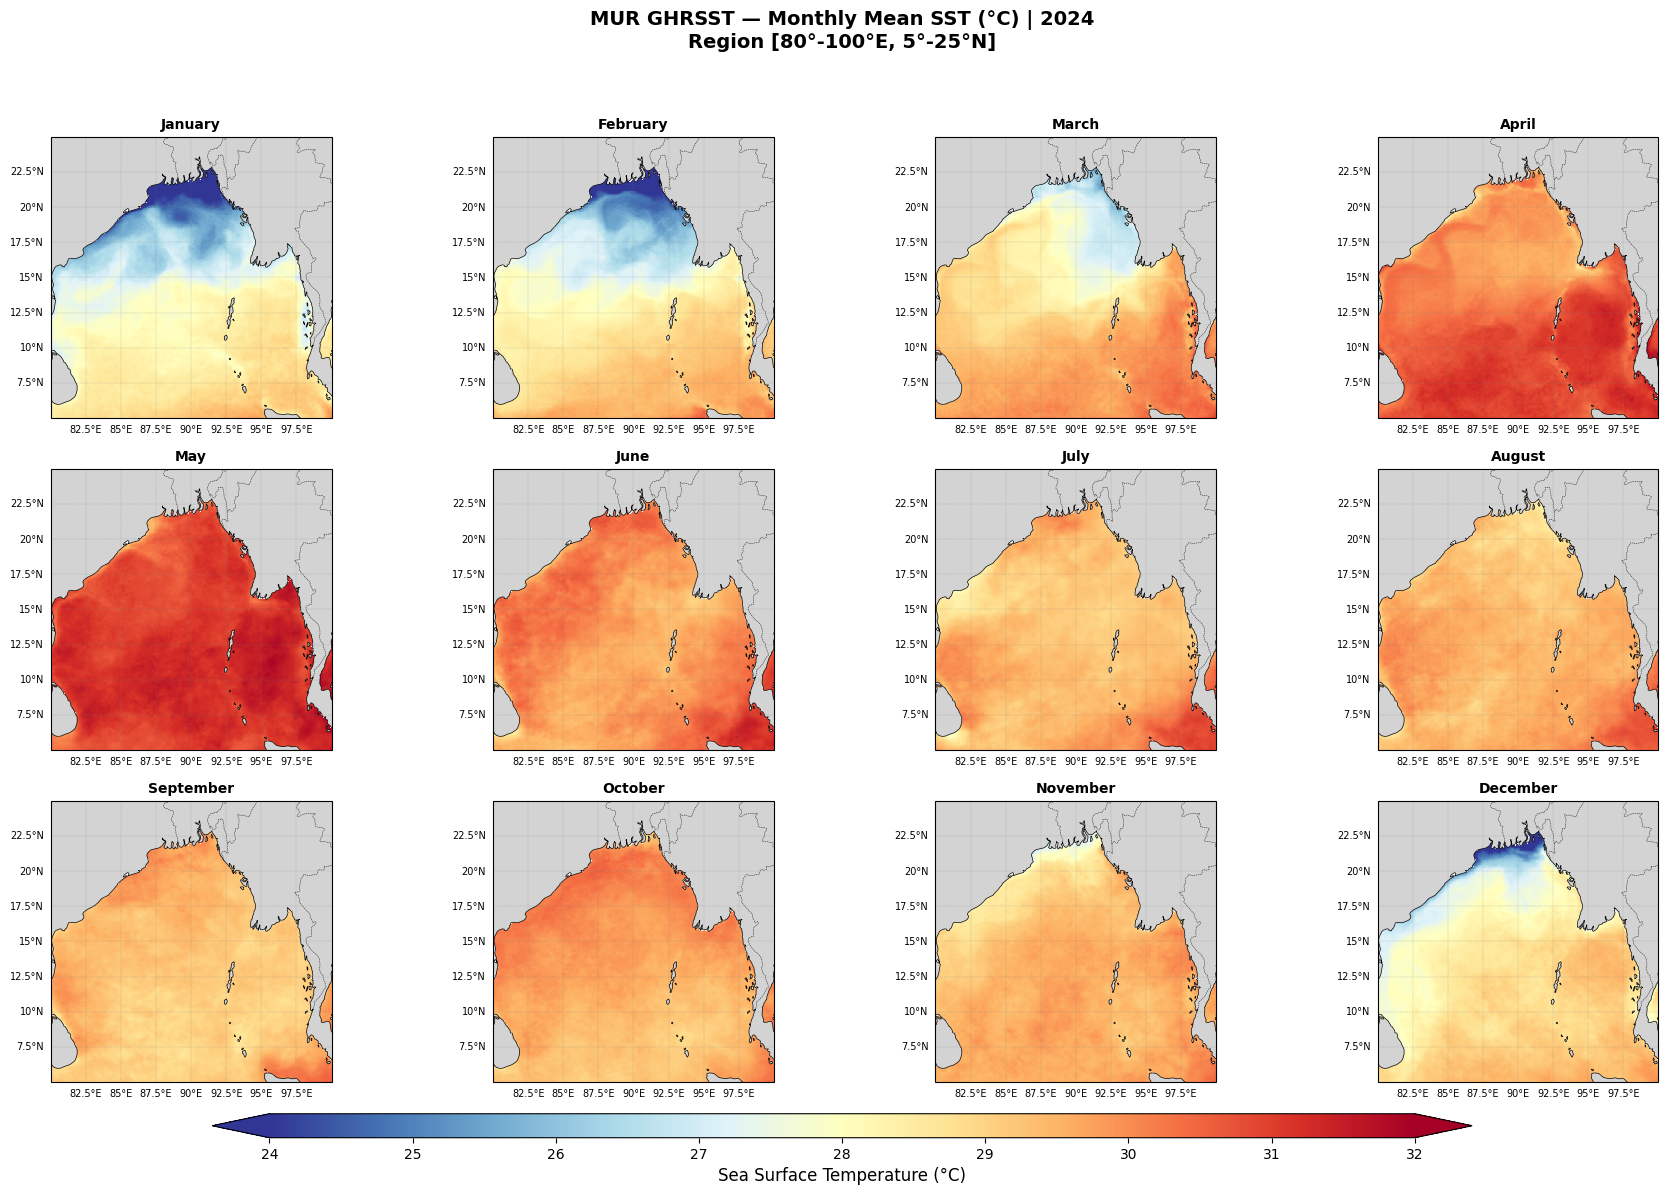

In [15]:
# Ensure output directory exists
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Create figure with 3x4 subplot grid
fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(18, 12),
                         subplot_kw={'projection': ccrs.PlateCarree()})
axes = axes.flatten()

img_handle = None
files_processed = 0

# Process each month
for month_idx in range(12):
    month_num = month_idx + 1
    ax = axes[month_idx]
    
    print(f"Processing {month_name[month_num]} {YEAR}...", end=" ")
    
    # Get files for this month
    month_files = get_files_for_month(all_files, YEAR, month_num)
    
    if len(month_files) == 0:
        # No data for this month
        ax.set_title(f"{month_name[month_num]} (no data)", fontsize=10)
        ax.axis('off')
        print("no data")
        continue
    
    # Load all daily SST arrays for this month
    daily_sst_list = []
    for day, filepath in sorted(month_files.items()):
        try:
            sst = load_sst(filepath, REGION, DOWNSAMPLE)
            daily_sst_list.append(sst)
            files_processed += 1
        except Exception as e:
            print(f"\n    Warning: Failed to load day {day}: {e}")
    
    if len(daily_sst_list) == 0:
        ax.set_title(f"{month_name[month_num]} (load error)", fontsize=10)
        ax.axis('off')
        print("load error")
        continue
    
    # Stack and compute monthly mean
    monthly_stack = xr.concat(daily_sst_list, dim='day')
    monthly_mean = monthly_stack.mean(dim='day')
    
    # Plot
    img_handle = make_sst_map(ax, monthly_mean, month_name[month_num], SST_VMIN, SST_VMAX, SST_CMAP, show_cbar=False)
    
    # Set extent if region is specified
    if REGION is not None:
        ax.set_extent(REGION, crs=ccrs.PlateCarree())
    
    print(f"done ({len(daily_sst_list)} days)")

# Add shared colorbar at bottom with finer tick resolution
if img_handle is not None:
    cbar_ax = fig.add_axes([0.15, 0.04, 0.7, 0.02])
    cbar = fig.colorbar(img_handle, cax=cbar_ax, orientation='horizontal', extend='both')
    
    # Set ticks at 1°C intervals for finer resolution
    tick_interval = 1.0 if (SST_VMAX - SST_VMIN) <= 10 else 2.0
    ticks = np.arange(SST_VMIN, SST_VMAX + tick_interval, tick_interval)
    cbar.set_ticks(ticks)
    cbar.ax.tick_params(labelsize=10)
    cbar.set_label('Sea Surface Temperature (°C)', fontsize=12)

# Main title
region_str = "Global" if REGION is None else f"Region [{REGION[0]}°-{REGION[1]}°E, {REGION[2]}°-{REGION[3]}°N]"
fig.suptitle(f"MUR GHRSST — Monthly Mean SST (°C) | {YEAR}\n{region_str}",
             fontsize=14, fontweight='bold', y=0.98)

plt.tight_layout(rect=[0, 0.06, 1, 0.95])

# Save figure with updated colorbar range in filename
monthly_plot_path = os.path.join(OUTPUT_DIR, f"SST_Monthly_Mean_{YEAR}_range{int(SST_VMIN)}-{int(SST_VMAX)}C.png")
fig.savefig(monthly_plot_path, dpi=150, bbox_inches='tight', facecolor='white')

print(f"\nMonthly plot saved: {monthly_plot_path}")
print(f"Total files processed: {files_processed}")
print(f"Colorbar range: {SST_VMIN}°C to {SST_VMAX}°C")

plt.show()

---
## Block 4: Daily Plots (Flexible Date Range)

Create a panel figure showing daily SST maps for every day in the specified date range.

In [16]:
# Get files for the specified month
month_files = get_files_for_month(all_files, YEAR, DAILY_MONTH)

# Filter to the requested day range
days_to_plot = []
for day in range(DAILY_DAY_START, DAILY_DAY_END + 1):
    if day in month_files:
        days_to_plot.append((day, month_files[day]))

print(f"Plotting {len(days_to_plot)} days for {month_name[DAILY_MONTH]} {YEAR}")
print(f"Day range: {DAILY_DAY_START} - {DAILY_DAY_END}")

if len(days_to_plot) == 0:
    print(f"\nERROR: No data files found for {month_name[DAILY_MONTH]} {YEAR}, "
          f"days {DAILY_DAY_START}-{DAILY_DAY_END}")

Plotting 30 days for May 2024
Day range: 1 - 30


  Plotting October 01... done
  Plotting October 02... done
  Plotting October 03... done
  Plotting October 04... done
  Plotting October 05... done
  Plotting October 06... done
  Plotting October 07... done
  Plotting October 08... done
  Plotting October 09... done
  Plotting October 10... done
  Plotting October 11... done
  Plotting October 12... done
  Plotting October 13... done
  Plotting October 14... done
  Plotting October 15... done
  Plotting October 16... done
  Plotting October 17... done
  Plotting October 18... done
  Plotting October 19... done
  Plotting October 20... done
  Plotting October 21... done
  Plotting October 22... done
  Plotting October 23... done
  Plotting October 24... done
  Plotting October 25... done
  Plotting October 26... done
  Plotting October 27... done
  Plotting October 28... done
  Plotting October 29... done
  Plotting October 30... done

Daily plot saved: C:\Users\abhik\Downloads\New_folder\SST_Plots\SST_Daily_2024_10_Day01-30_range10-

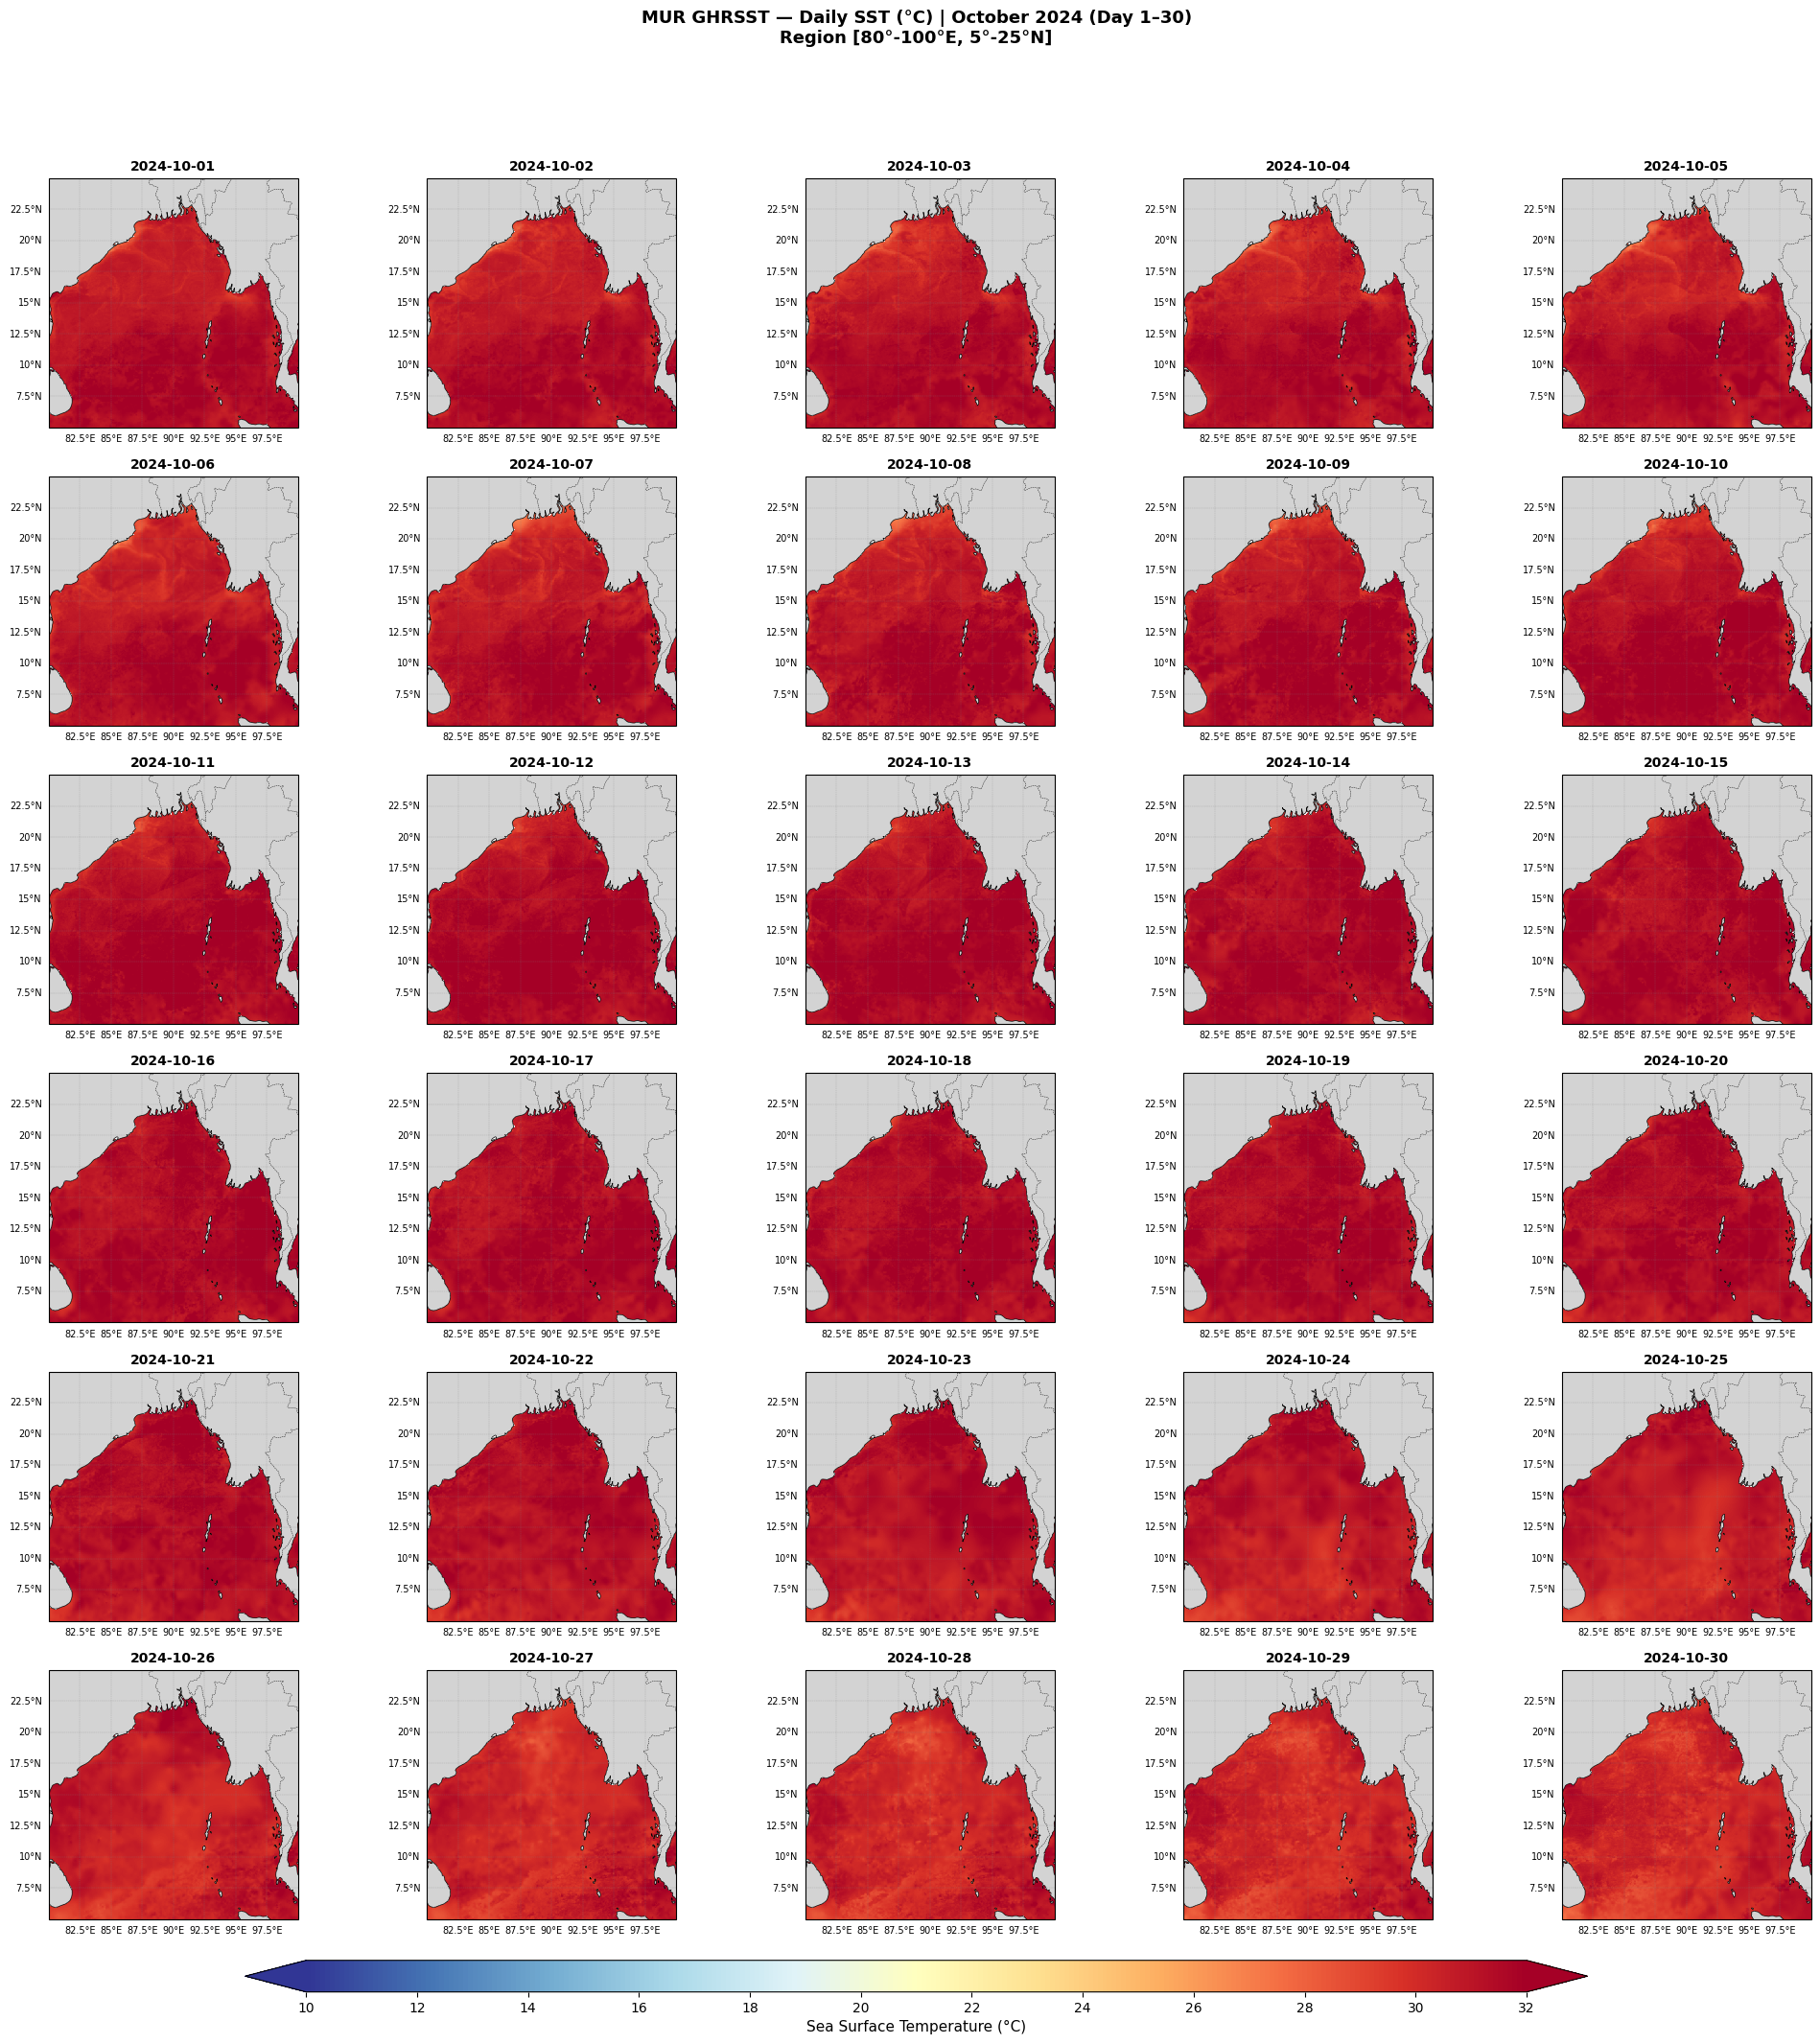

In [19]:
if len(days_to_plot) > 0:
    # Compute subplot grid dimensions
    n_days = len(days_to_plot)
    ncols = min(DAYS_PER_ROW, n_days)
    nrows = ceil(n_days / ncols)
    
    # Create figure
    fig_width = 4 * ncols
    fig_height = 3.5 * nrows + 1  # Extra space for colorbar
    
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols,
                             figsize=(fig_width, fig_height),
                             subplot_kw={'projection': ccrs.PlateCarree()})
    
    # Handle single row/column cases
    if nrows == 1 and ncols == 1:
        axes = np.array([[axes]])
    elif nrows == 1:
        axes = axes.reshape(1, -1)
    elif ncols == 1:
        axes = axes.reshape(-1, 1)
    
    axes_flat = axes.flatten()
    
    img_handle = None
    
    # Plot each day
    for idx, (day, filepath) in enumerate(days_to_plot):
        ax = axes_flat[idx]
        
        date_str = f"{YEAR}-{DAILY_MONTH:02d}-{day:02d}"
        print(f"  Plotting {month_name[DAILY_MONTH]} {day:02d}...", end=" ")
        
        try:
            sst = load_sst(filepath, REGION, DOWNSAMPLE)
            img_handle = make_sst_map(ax, sst, date_str, SST_VMIN, SST_VMAX, SST_CMAP,
                                       show_cbar=False)
            
            # Set extent if region is specified
            if REGION is not None:
                ax.set_extent(REGION, crs=ccrs.PlateCarree())
            
            print("done")
        
        except Exception as e:
            ax.set_title(f"{date_str}\n(error)", fontsize=9)
            ax.axis('off')
            print(f"error: {e}")
    
    # Hide unused axes
    for idx in range(n_days, len(axes_flat)):
        axes_flat[idx].axis('off')
    
    # Add shared colorbar at bottom with finer tick resolution
    if img_handle is not None:
        cbar_ax = fig.add_axes([0.15, 0.04, 0.7, 0.015])
        cbar = fig.colorbar(img_handle, cax=cbar_ax, orientation='horizontal',
                            extend='both')
        
        # Set ticks at 1°C intervals for finer resolution
        tick_interval = 1.0 if (SST_VMAX - SST_VMIN) <= 10 else 2.0
        ticks = np.arange(SST_VMIN, SST_VMAX + tick_interval, tick_interval)
        cbar.set_ticks(ticks)
        cbar.ax.tick_params(labelsize=10)
        cbar.set_label('Sea Surface Temperature (°C)', fontsize=11)
    
    # Main title
    region_str = "Global" if REGION is None else f"Region [{REGION[0]}°-{REGION[1]}°E, {REGION[2]}°-{REGION[3]}°N]"
    fig.suptitle(f"MUR GHRSST — Daily SST (°C) | {month_name[DAILY_MONTH]} {YEAR} "
                 f"(Day {DAILY_DAY_START}–{DAILY_DAY_END})\n{region_str}",
                 fontsize=13, fontweight='bold', y=0.98)
    
    plt.tight_layout(rect=[0, 0.06, 1, 0.94])
    
    # Save figure with updated colorbar range in filename
    daily_filename = f"SST_Daily_{YEAR}_{DAILY_MONTH:02d}_Day{DAILY_DAY_START:02d}-{DAILY_DAY_END:02d}_range{int(SST_VMIN)}-{int(SST_VMAX)}C.png"
    daily_plot_path = os.path.join(OUTPUT_DIR, daily_filename)
    fig.savefig(daily_plot_path, dpi=150, bbox_inches='tight', facecolor='white')
    
    print(f"\nDaily plot saved: {daily_plot_path}")
    print(f"Colorbar range: {SST_VMIN}°C to {SST_VMAX}°C")
    
    plt.show()

---
## Output Summary

In [113]:
print("=" * 70)
print("OUTPUT SUMMARY")
print("=" * 70)
print(f"\nMonthly mean plot: {monthly_plot_path}")
if len(days_to_plot) > 0:
    print(f"Daily plot: {daily_plot_path}")
print(f"Total files in dataset: {len(all_files)}")
print(f"\nAnalysis complete!")

OUTPUT SUMMARY

Monthly mean plot: C:\Users\abhik\Downloads\New_folder\SST_Plots\SST_Monthly_Mean_2024_range24-32C.png
Daily plot: C:\Users\abhik\Downloads\New_folder\SST_Plots\SST_Daily_2024_01_Day01-30_range24-32C.png
Total files in dataset: 367

Analysis complete!
